# Eksperimen Hyperparameter Tuning

Notebook akan menguji beberapa komponen berikut:
1. pengaruh depth dan width
2. pengaruh fungsi aktivasi
3. pengaruh learning rate

Dari setiap komponen pengujian akan dibandingkan: 
1. Hasil akhir prediksinya
2. Grafik training loss dan validation loss tiap epoch setelah pelatihan
3. Distribusi bobot dan gradien bobot dari setiap layer pada model

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder
import ffnn

In [168]:
SEED=34

In [169]:
df = pd.read_csv("../data/dataset.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


In [170]:
df.describe()

,cgpa,backlogs,internship_count,aptitude_score,communication_score,internship_quality_score
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,6.998290,1.248100,1.49930,69.877531,65.158600,5.021436
std,0.802606,1.149904,1.20289,14.700532,14.740446,1.505975
min,4.000000,0.000000,0.00000,30.000000,30.000000,1.000000
25%,6.461928,0.000000,1.00000,59.880399,55.112244,4.012656
50%,6.997924,1.000000,1.00000,70.097368,65.006484,5.017335
75%,7.536865,2.000000,2.00000,80.213934,75.277248,6.031400
max,10.000000,6.000000,5.00000,100.000000,100.000000,10.000000


In [171]:
df.shape

(10000, 12)

# Data Preprocessing

we will label encode college_tier and university_ranking_band since they have an order

In [172]:
college_tier_map = {"Tier 3":0, "Tier 2":1, "Tier 1":2}
df["college_tier"] = df["college_tier"].map(college_tier_map)
df["college_tier"].value_counts()

college_tier
1    3993
2    3034
0    2973
Name: count, dtype: int64

In [173]:
ranking_map = {"300+":0,"100-300":1,"Top 100":2}
df["university_ranking_band"] = df["university_ranking_band"].map(ranking_map)
df["university_ranking_band"].value_counts()

university_ranking_band
0    4075
1    3975
2    1950
Name: count, dtype: int64

Target encoding for placement_status

In [174]:
target_map = {"Placed":1,"Not Placed":0}
df["placement_status"]=df["placement_status"].map(target_map)
df["placement_status"].value_counts()

placement_status
1    6153
0    3847
Name: count, dtype: int64

In [175]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,1,Canada,1,2,53.574150,64.177062,Data Science,Consulting,5.481450,1
1,6.889389,0,0,UK,0,1,60.687750,88.346052,Data Science,Consulting,4.625099,1
2,7.518151,0,2,UK,1,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,1
3,8.218424,0,1,UK,1,3,73.461500,78.204854,AI/ML,Tech,5.150674,1
4,6.812677,1,1,USA,1,4,86.518121,44.680881,Data Science,Consulting,3.888824,1


In [176]:
categorical_col = df.select_dtypes(include=["object"]).columns
print(categorical_col)

Index(['country', 'specialization', 'industry'], dtype='str')


/tmp/ipykernel_3739/1470084899.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include=["object"]).columns


In [177]:
num_cols = df.select_dtypes(exclude=["object"]).columns
print(num_cols)

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score', 'placement_status'],
      dtype='str')


### Preprocessing Pipeline

In [178]:
transformed_df = df.copy()

In [179]:
ss = StandardScaler()
ss.set_output(transform="pandas")

transformed_num_cols = transformed_df.select_dtypes(exclude="object").columns.drop("placement_status")
print(transformed_num_cols)

transformed_num_df = ss.fit_transform(transformed_df[transformed_num_cols])
transformed_num_df.head()

Index(['cgpa', 'backlogs', 'college_tier', 'university_ranking_band',
       'internship_count', 'aptitude_score', 'communication_score',
       'internship_quality_score'],
      dtype='str')


,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116


In [180]:
oh_cols = ["country","specialization","industry"]

In [181]:
onehot = OneHotEncoder(sparse_output=False)

one_hot_encoded = onehot.fit_transform(transformed_df[oh_cols])


one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=onehot.get_feature_names_out(oh_cols))

transformed_encoded_df = pd.concat([transformed_num_df, one_hot_df], axis=1)

transformed_encoded_df.head()

,cgpa,backlogs,college_tier,university_ranking_band,internship_count,aptitude_score,communication_score,internship_quality_score,country_Canada,country_Germany,...,specialization_Cloud,specialization_Core CS,specialization_Cybersecurity,specialization_Data Science,industry_Consulting,industry_Finance,industry_Healthcare,industry_Manufacturing,industry_Other,industry_Tech
0,0.497257,-0.215768,-0.007871,0.284641,0.416268,-1.109089,-0.066591,0.305474,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.135691,-1.085449,-1.298153,-1.054846,-0.415104,-0.625164,1.573128,-0.263189,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.647749,-1.085449,1.282411,0.284641,0.416268,-0.361147,0.294074,0.137129,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.520292,-1.085449,-0.007871,0.284641,1.247641,0.243811,0.885109,0.085821,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.231274,-0.215768,-0.007871,0.284641,2.079014,1.132029,-1.389289,-0.752116,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


# Modelling Experiment

In [182]:
X = transformed_encoded_df
y = transformed_df["placement_status"].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=SEED)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 24), (2000, 24), (8000,), (2000,))

### Control Model

The model's performance is compared with other model variation

In [183]:
control_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [184]:
control_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
control_preds = control_model.predict(X_test)
print(f1_score(y_test,control_preds))

Epoch 1/20 [==============================] - train_loss: 0.523599 - val_loss: 0.530938
Epoch 2/20 [==============================] - train_loss: 0.517025 - val_loss: 0.525067
Epoch 3/20 [==============================] - train_loss: 0.516501 - val_loss: 0.524213
Epoch 4/20 [==============================] - train_loss: 0.511611 - val_loss: 0.512730
Epoch 5/20 [==============================] - train_loss: 0.512426 - val_loss: 0.517353
Epoch 6/20 [==============================] - train_loss: 0.526431 - val_loss: 0.531251
Epoch 7/20 [==============================] - train_loss: 0.516247 - val_loss: 0.523069
Epoch 8/20 [==============================] - train_loss: 0.508896 - val_loss: 0.519484
Epoch 9/20 [==============================] - train_loss: 0.510068 - val_loss: 0.518571
Epoch 10/20 [==============================] - train_loss: 0.512681 - val_loss: 0.518044
Epoch 11/20 [==============================] - train_loss: 0.509303 - val_loss: 0.514437
Epoch 12/20 [=================

### Three variation of width with the same depth like the control

Width variation: 2, 8, and 64

In [185]:
w1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 2), ffnn.Relu(), ffnn.Linear(2, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 8), ffnn.Relu(), ffnn.Linear(8, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

w3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 64), ffnn.Relu(), ffnn.Linear(64, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [186]:
w1_history = w1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w1_preds = w1_model.predict(X_test)
print(f"width = 2: {f1_score(y_test, w1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.523366 - val_loss: 0.531557
Epoch 2/20 [==============================] - train_loss: 0.517559 - val_loss: 0.524044
Epoch 3/20 [==============================] - train_loss: 0.521042 - val_loss: 0.526145
Epoch 4/20 [==============================] - train_loss: 0.512153 - val_loss: 0.511486
Epoch 5/20 [==============================] - train_loss: 0.514125 - val_loss: 0.518615
Epoch 6/20 [==============================] - train_loss: 0.526989 - val_loss: 0.529943
Epoch 7/20 [==============================] - train_loss: 0.517412 - val_loss: 0.521992
Epoch 8/20 [==============================] - train_loss: 0.509841 - val_loss: 0.518440
Epoch 9/20 [==============================] - train_loss: 0.512237 - val_loss: 0.518347
Epoch 10/20 [==============================] - train_loss: 0.513199 - val_loss: 0.518586
Epoch 11/20 [==============================] - train_loss: 0.515759 - val_loss: 0.518087
Epoch 12/20 [=================

In [187]:
w2_history = w2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w2_preds = w2_model.predict(X_test)
print(f"width = 8: {f1_score(y_test, w2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.524903 - val_loss: 0.530941
Epoch 2/20 [==============================] - train_loss: 0.521466 - val_loss: 0.527444
Epoch 3/20 [==============================] - train_loss: 0.522010 - val_loss: 0.528446
Epoch 4/20 [==============================] - train_loss: 0.514389 - val_loss: 0.515253
Epoch 5/20 [==============================] - train_loss: 0.515509 - val_loss: 0.520695
Epoch 6/20 [==============================] - train_loss: 0.527224 - val_loss: 0.532097
Epoch 7/20 [==============================] - train_loss: 0.518794 - val_loss: 0.525015
Epoch 8/20 [==============================] - train_loss: 0.509274 - val_loss: 0.518486
Epoch 9/20 [==============================] - train_loss: 0.511953 - val_loss: 0.519985
Epoch 10/20 [==============================] - train_loss: 0.514342 - val_loss: 0.519965
Epoch 11/20 [==============================] - train_loss: 0.508420 - val_loss: 0.513054
Epoch 12/20 [=================

In [188]:
w3_history = w3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
w3_preds = w3_model.predict(X_test)
print(f"width = 64: {f1_score(y_test, w3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.534616 - val_loss: 0.545590
Epoch 2/20 [==============================] - train_loss: 0.523147 - val_loss: 0.534133
Epoch 3/20 [==============================] - train_loss: 0.522315 - val_loss: 0.531252
Epoch 4/20 [==============================] - train_loss: 0.514383 - val_loss: 0.516895
Epoch 5/20 [==============================] - train_loss: 0.515499 - val_loss: 0.521661
Epoch 6/20 [==============================] - train_loss: 0.526195 - val_loss: 0.531786
Epoch 7/20 [==============================] - train_loss: 0.518204 - val_loss: 0.524435
Epoch 8/20 [==============================] - train_loss: 0.509219 - val_loss: 0.519139
Epoch 9/20 [==============================] - train_loss: 0.511496 - val_loss: 0.520200
Epoch 10/20 [==============================] - train_loss: 0.512713 - val_loss: 0.518732
Epoch 11/20 [==============================] - train_loss: 0.508183 - val_loss: 0.512802
Epoch 12/20 [=================

#### Perbandingan

In [189]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"width = 2: {f1_score(y_test, w1_preds)}")
print(f"width = 8: {f1_score(y_test, w2_preds)}")
print(f"width = 64: {f1_score(y_test, w3_preds)}")

control: 0.7680345572354211


width = 2: 0.7654213727193745
width = 8: 0.7700854700854701
width = 64: 0.7691648822269808


##### W1 Distribution + Gradient Weight Plot

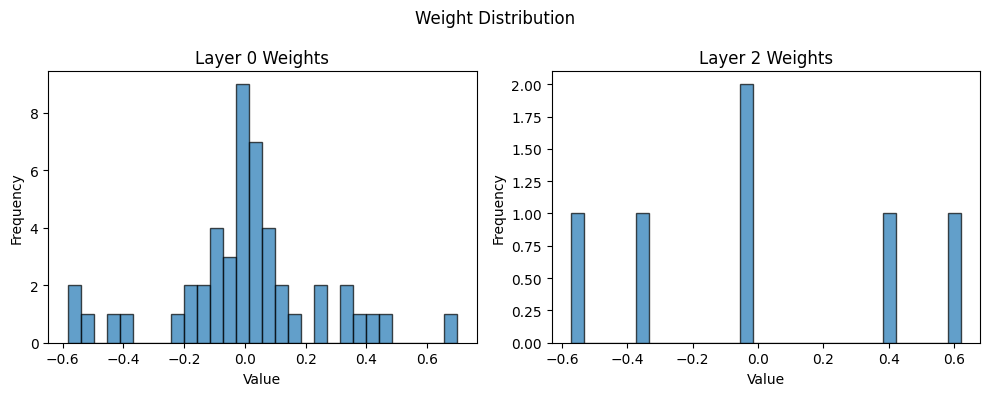

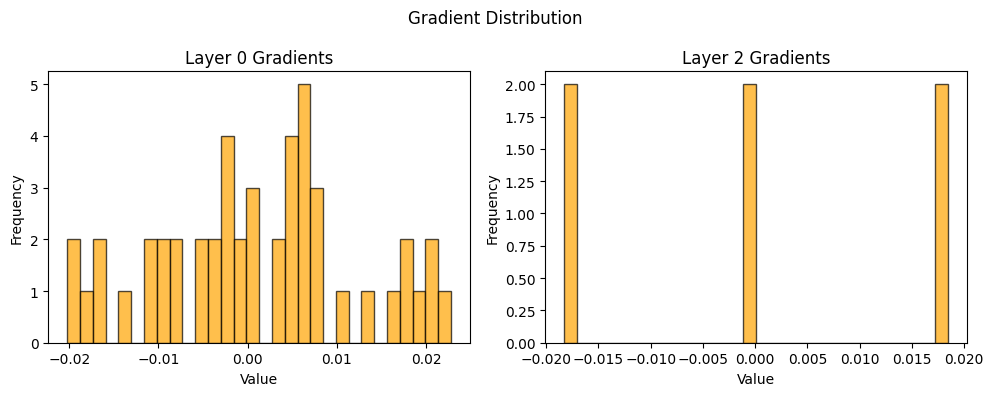

In [190]:
w1_layers = [0, 2]

w1_model.plot_weights(w1_layers)

w1_model.plot_gradients(w1_layers)

##### W2 Distribution + Gradient Weight Plot

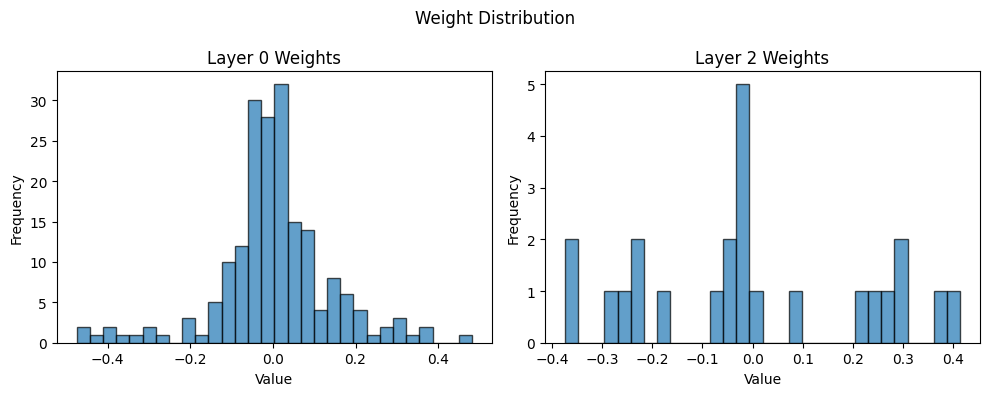

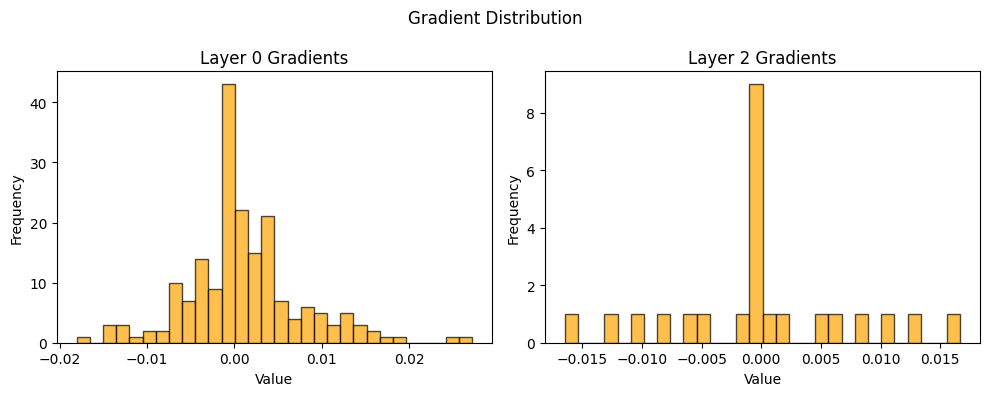

In [191]:
w2_layers = [0, 2]

w2_model.plot_weights(w2_layers)

w2_model.plot_gradients(w2_layers)

##### W3 Distribution + Gradient Weight Plot

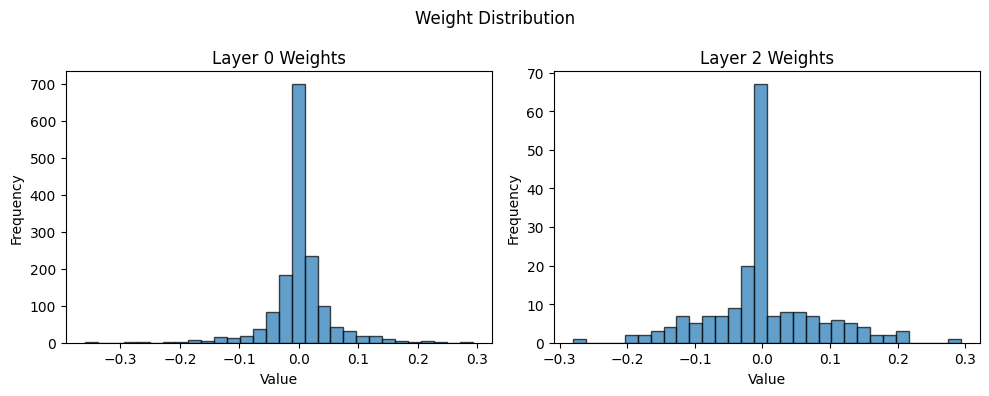

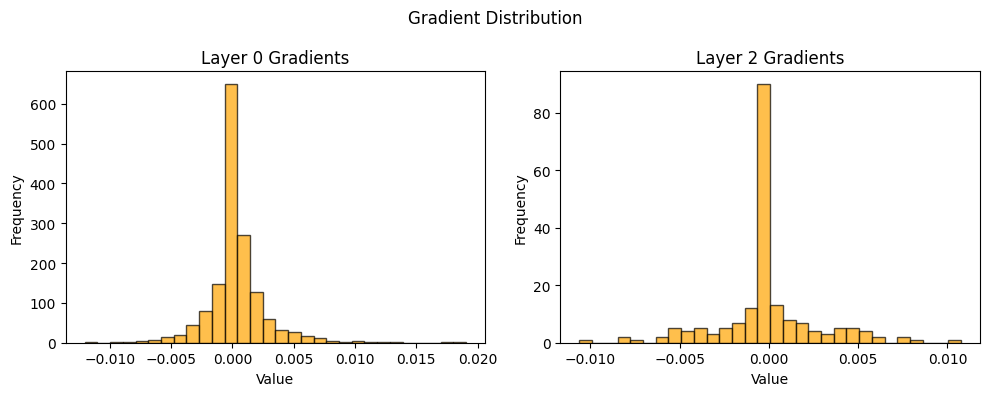

In [192]:
w3_layers = [0, 2]

w3_model.plot_weights(w3_layers)

w3_model.plot_gradients(w3_layers)

### Three variation of depth with the same width like the control

Depth variation (hidden layers): 
- 2
- 4
- 8


In [ ]:
h1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 12), 
            ffnn.Relu(), 
            ffnn.Linear(12, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 20), 
            ffnn.Relu(), 
            ffnn.Linear(20, 16), 
            ffnn.Relu(), 
            ffnn.Linear(16, 12), 
            ffnn.Relu(),
            ffnn.Linear(12, 4), 
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

h3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 20), 
            ffnn.Relu(), 
            ffnn.Linear(20, 18),
            ffnn.Relu(),
            ffnn.Linear(18, 14),
            ffnn.Relu(),
            ffnn.Linear(14, 12),
            ffnn.Relu(),
            ffnn.Linear(12, 8),
            ffnn.Relu(),
            ffnn.Linear(8, 6),
            ffnn.Relu(),
            ffnn.Linear(6, 14),
            ffnn.Relu(),
            ffnn.Linear(4, 4),
            ffnn.Relu(),
            ffnn.Linear(4, 3), 
            ffnn.Softmax()
            ],
    loss=ffnn.CrossEntropyLoss(),
)

In [194]:
h1_history = h1_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h1_preds = h1_model.predict(X_test)
print(f"hidden layer depth = 2: {f1_score(y_test,h1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.533536 - val_loss: 0.546293
Epoch 2/20 [==============================] - train_loss: 0.525542 - val_loss: 0.536723
Epoch 3/20 [==============================] - train_loss: 0.526243 - val_loss: 0.533367
Epoch 4/20 [==============================] - train_loss: 0.517120 - val_loss: 0.519316
Epoch 5/20 [==============================] - train_loss: 0.519903 - val_loss: 0.524848
Epoch 6/20 [==============================] - train_loss: 0.527173 - val_loss: 0.531934
Epoch 7/20 [==============================] - train_loss: 0.522488 - val_loss: 0.528357
Epoch 8/20 [==============================] - train_loss: 0.515862 - val_loss: 0.527467
Epoch 9/20 [==============================] - train_loss: 0.514916 - val_loss: 0.522994
Epoch 10/20 [==============================] - train_loss: 0.518189 - val_loss: 0.523949
Epoch 11/20 [==============================] - train_loss: 0.517734 - val_loss: 0.523230
Epoch 12/20 [=================

In [195]:
h2_history = h2_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h2_preds = h2_model.predict(X_test)
print(f"hidden layer depth = 4: {f1_score(y_test,h2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.553868 - val_loss: 0.564421
Epoch 2/20 [==============================] - train_loss: 0.541002 - val_loss: 0.551059
Epoch 3/20 [==============================] - train_loss: 0.539460 - val_loss: 0.546020
Epoch 4/20 [==============================] - train_loss: 0.523487 - val_loss: 0.527164
Epoch 5/20 [==============================] - train_loss: 0.524519 - val_loss: 0.530994
Epoch 6/20 [==============================] - train_loss: 0.530112 - val_loss: 0.535191
Epoch 7/20 [==============================] - train_loss: 0.528057 - val_loss: 0.534667
Epoch 8/20 [==============================] - train_loss: 0.520031 - val_loss: 0.530948
Epoch 9/20 [==============================] - train_loss: 0.519557 - val_loss: 0.528005
Epoch 10/20 [==============================] - train_loss: 0.522169 - val_loss: 0.528218
Epoch 11/20 [==============================] - train_loss: 0.526069 - val_loss: 0.532367
Epoch 12/20 [=================

In [196]:
h3_history = h3_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
h3_preds = h3_model.predict(X_test)
print(f"hidden layer depth = 8: {f1_score(y_test,h3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.607974 - val_loss: 0.615203
Epoch 2/20 [==============================] - train_loss: 0.560927 - val_loss: 0.569513
Epoch 3/20 [==============================] - train_loss: 0.550170 - val_loss: 0.557407
Epoch 4/20 [==============================] - train_loss: 0.532294 - val_loss: 0.533538
Epoch 5/20 [==============================] - train_loss: 0.537452 - val_loss: 0.543436
Epoch 6/20 [==============================] - train_loss: 0.540975 - val_loss: 0.546879
Epoch 7/20 [==============================] - train_loss: 0.548450 - val_loss: 0.553686
Epoch 8/20 [==============================] - train_loss: 0.537469 - val_loss: 0.545053
Epoch 9/20 [==============================] - train_loss: 0.529499 - val_loss: 0.535764
Epoch 10/20 [==============================] - train_loss: 0.533374 - val_loss: 0.540253
Epoch 11/20 [==============================] - train_loss: 0.533776 - val_loss: 0.540129
Epoch 12/20 [=================

#### Perbandingan

In [197]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"hidden layer depth = 2: {f1_score(y_test,h1_preds)}")
print(f"hidden layer depth = 4: {f1_score(y_test,h2_preds)}")
print(f"hidden layer depth = 8: {f1_score(y_test,h3_preds)}")

control: 0.7680345572354211
hidden layer depth = 2: 0.7570921985815603
hidden layer depth = 4: 0.7579135086937138
hidden layer depth = 8: 0.6622039134912462


##### H1 Distribution + Gradient Weight Plot

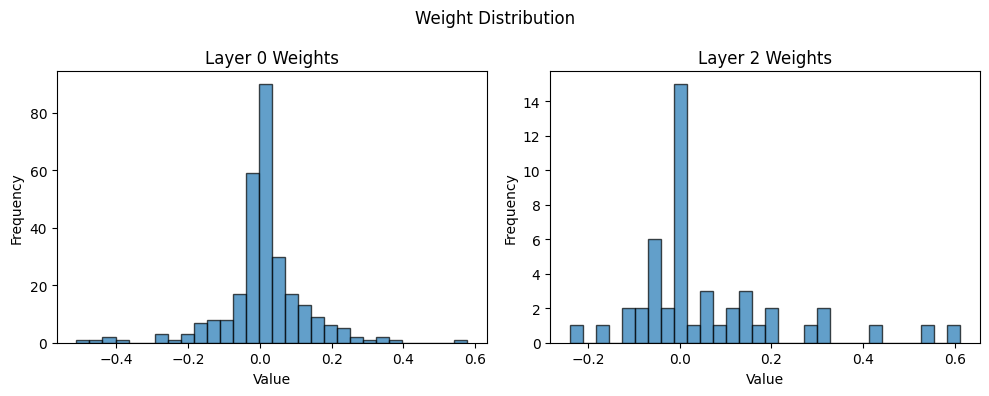

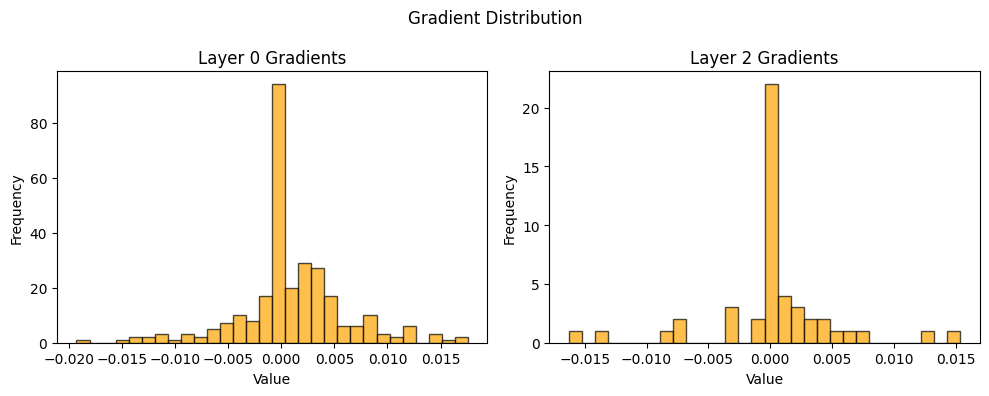

In [198]:
h1_layers = [0, 2]

h1_model.plot_weights(h1_layers)

h1_model.plot_gradients(h1_layers)

##### H2 Distribution + Gradient Weight Plot

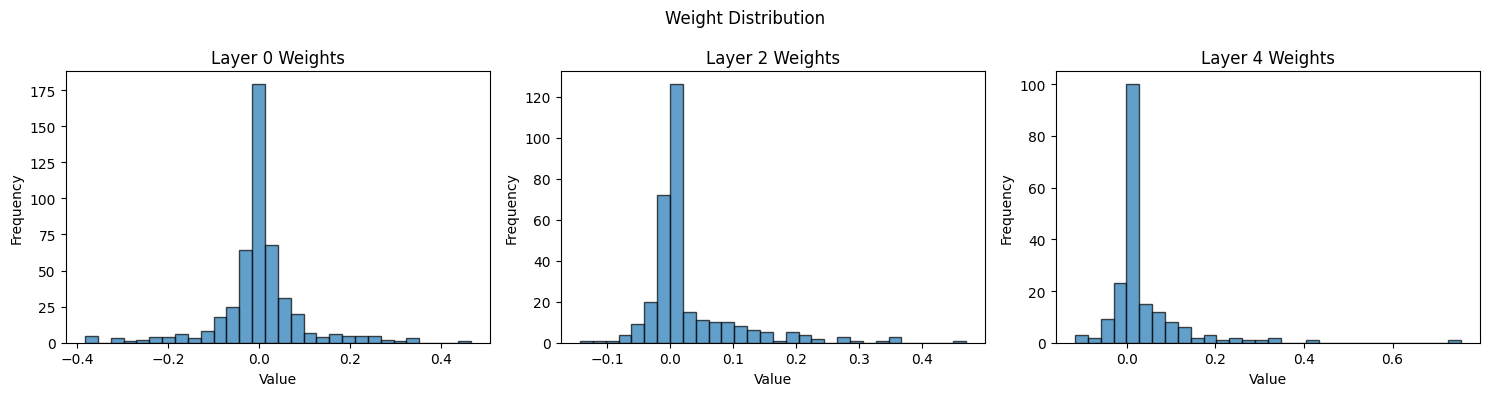

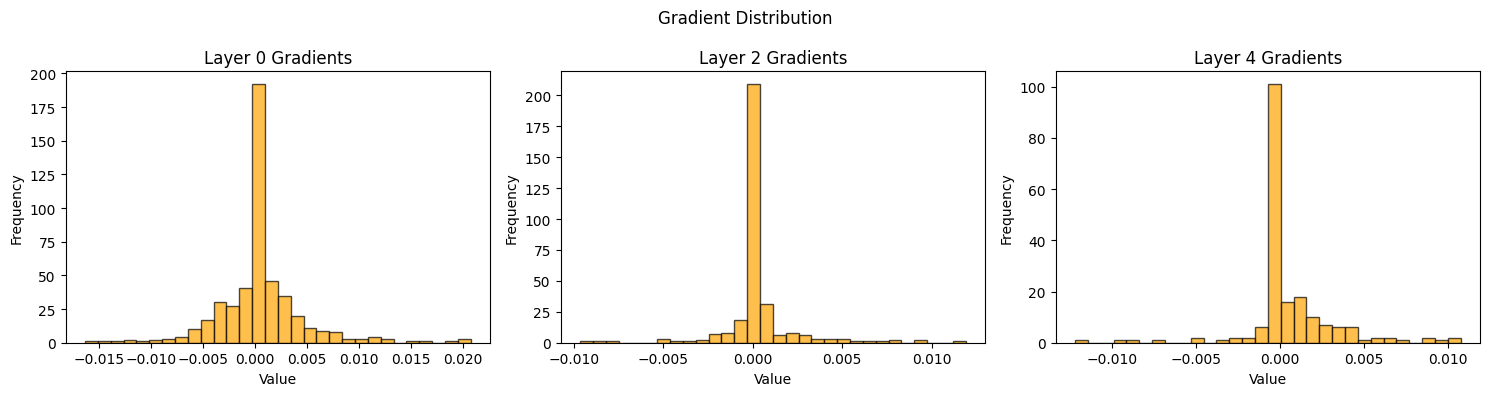

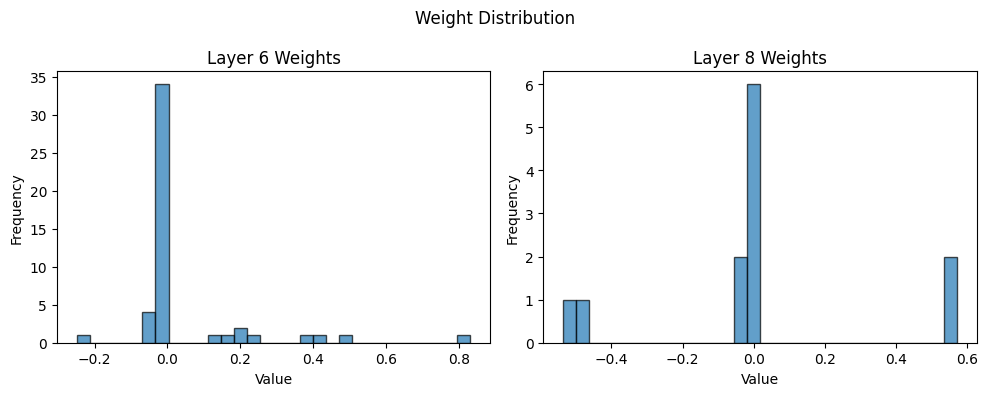

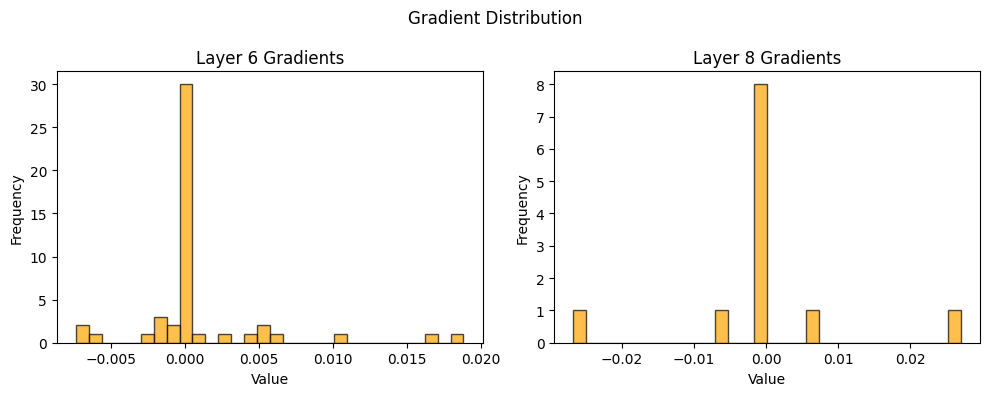

In [199]:
h2_layers = [0, 2, 4]

h2_model.plot_weights(h2_layers)

h2_model.plot_gradients(h2_layers)

h2_layers = [6, 8]

h2_model.plot_weights(h2_layers)

h2_model.plot_gradients(h2_layers)

##### H3 Distribution + Gradient Weight Plot

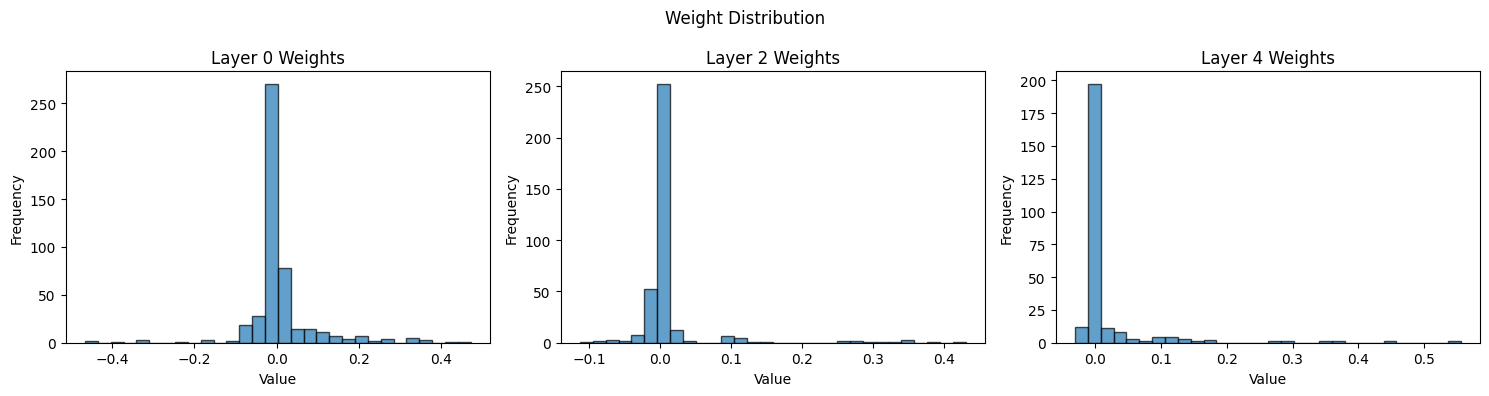

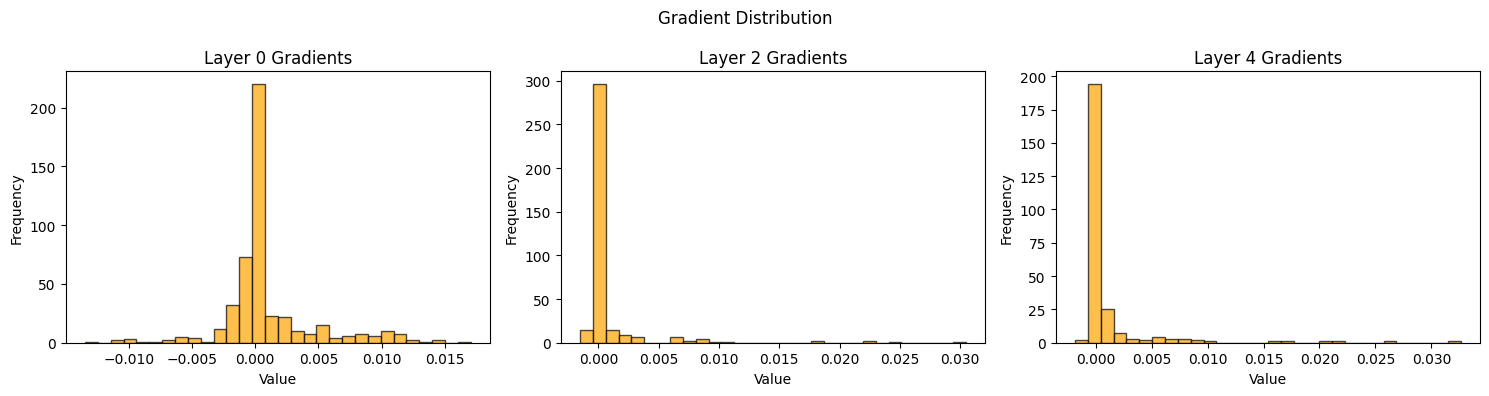

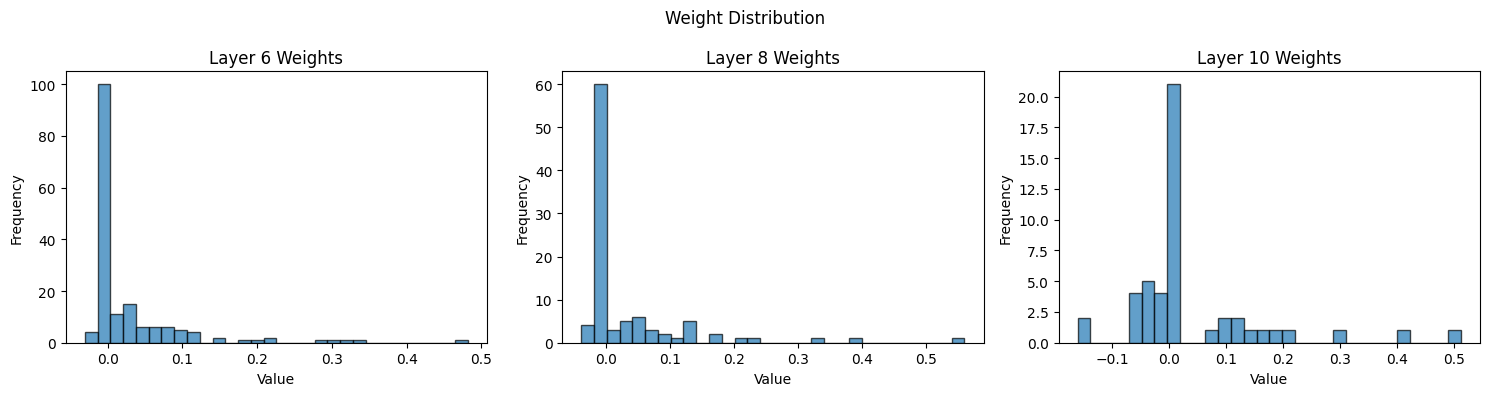

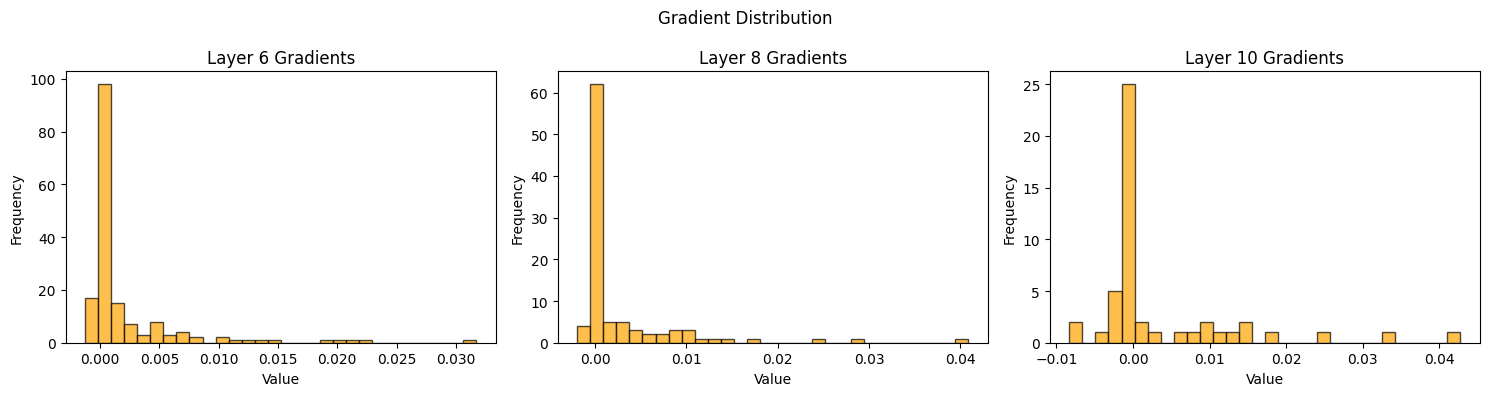

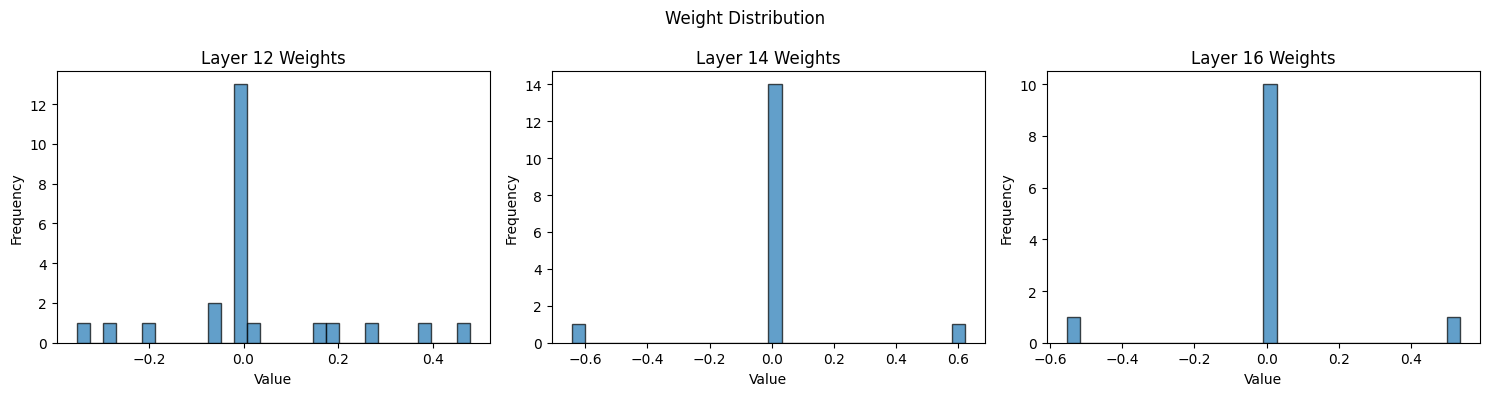

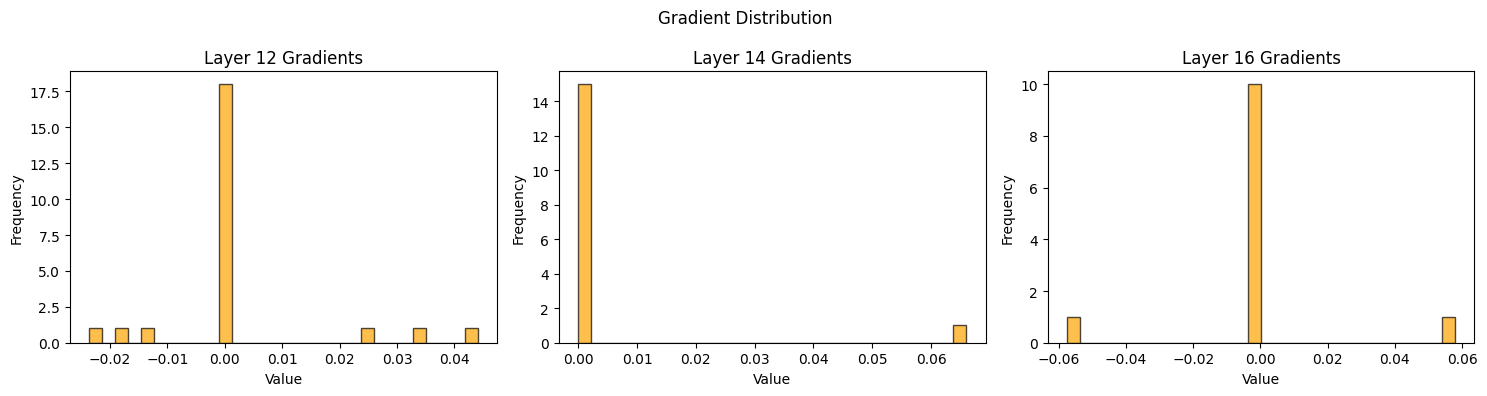

In [200]:
h3_layers = [0, 2, 4]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

h3_layers = [6, 8, 10]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

h3_layers = [12, 14, 16]

h3_model.plot_weights(h3_layers)

h3_model.plot_gradients(h3_layers)

### All variation of Activation Layer

FFNN is structured to have one of each input, hidden and output layer

Hidden layer variations are:

- RELU
- Leaky RELU
- ELU
- Sigmoid
- Tanh
- RMS Norm

In [201]:
relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

leaky_relu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.LeakyRelu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

elu_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.ELU(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

sigmoid_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Sigmoid(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

tanh_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Tanh(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

rmsnorm_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.RMSNorm(4), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)




In [202]:
relu_history = relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
relu_preds = relu_model.predict(X_test)
print(f"hidden layer activation = RELU: {f1_score(y_test,relu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.533537 - val_loss: 0.540671
Epoch 2/20 [==============================] - train_loss: 0.520279 - val_loss: 0.525917
Epoch 3/20 [==============================] - train_loss: 0.518681 - val_loss: 0.525043
Epoch 4/20 [==============================] - train_loss: 0.512443 - val_loss: 0.512877
Epoch 5/20 [==============================] - train_loss: 0.514403 - val_loss: 0.518824
Epoch 6/20 [==============================] - train_loss: 0.519144 - val_loss: 0.523026
Epoch 7/20 [==============================] - train_loss: 0.515747 - val_loss: 0.519979
Epoch 8/20 [==============================] - train_loss: 0.510678 - val_loss: 0.519833
Epoch 9/20 [==============================] - train_loss: 0.513364 - val_loss: 0.520193
Epoch 10/20 [==============================] - train_loss: 0.515343 - val_loss: 0.519040
Epoch 11/20 [==============================] - train_loss: 0.512269 - val_loss: 0.515859
Epoch 12/20 [=================

In [203]:
leaky_relu_history = leaky_relu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
leaky_relu_preds = leaky_relu_model.predict(X_test)
print(f"hidden layer activation = Leaky RELU: {f1_score(y_test, leaky_relu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.522277 - val_loss: 0.530040
Epoch 2/20 [==============================] - train_loss: 0.520661 - val_loss: 0.528017
Epoch 3/20 [==============================] - train_loss: 0.522659 - val_loss: 0.529923
Epoch 4/20 [==============================] - train_loss: 0.515734 - val_loss: 0.516610
Epoch 5/20 [==============================] - train_loss: 0.516932 - val_loss: 0.521975
Epoch 6/20 [==============================] - train_loss: 0.529074 - val_loss: 0.532988
Epoch 7/20 [==============================] - train_loss: 0.520198 - val_loss: 0.525315
Epoch 8/20 [==============================] - train_loss: 0.511297 - val_loss: 0.519264
Epoch 9/20 [==============================] - train_loss: 0.512686 - val_loss: 0.519211
Epoch 10/20 [==============================] - train_loss: 0.513809 - val_loss: 0.518211
Epoch 11/20 [==============================] - train_loss: 0.512234 - val_loss: 0.514572
Epoch 12/20 [=================

In [204]:
elu_history = elu_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
elu_preds = elu_model.predict(X_test)
print(f"hidden layer activation = ELU: {f1_score(y_test, elu_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.526270 - val_loss: 0.533132
Epoch 2/20 [==============================] - train_loss: 0.518589 - val_loss: 0.524434
Epoch 3/20 [==============================] - train_loss: 0.517667 - val_loss: 0.523391
Epoch 4/20 [==============================] - train_loss: 0.512064 - val_loss: 0.511684
Epoch 5/20 [==============================] - train_loss: 0.512208 - val_loss: 0.515472
Epoch 6/20 [==============================] - train_loss: 0.522611 - val_loss: 0.525029
Epoch 7/20 [==============================] - train_loss: 0.515211 - val_loss: 0.518858
Epoch 8/20 [==============================] - train_loss: 0.507652 - val_loss: 0.514651
Epoch 9/20 [==============================] - train_loss: 0.510518 - val_loss: 0.515548
Epoch 10/20 [==============================] - train_loss: 0.510210 - val_loss: 0.512835
Epoch 11/20 [==============================] - train_loss: 0.505703 - val_loss: 0.507970
Epoch 12/20 [=================

In [205]:
rmsnorm_history = rmsnorm_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
rmsnorm_preds = rmsnorm_model.predict(X_test)
print(f"hidden layer activation = RMS Norm: {f1_score(y_test, rmsnorm_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.548963 - val_loss: 0.562674
Epoch 2/20 [==============================] - train_loss: 0.525307 - val_loss: 0.533034
Epoch 3/20 [==============================] - train_loss: 0.522301 - val_loss: 0.528969
Epoch 4/20 [==============================] - train_loss: 0.516196 - val_loss: 0.515744
Epoch 5/20 [==============================] - train_loss: 0.515213 - val_loss: 0.519529
Epoch 6/20 [==============================] - train_loss: 0.525492 - val_loss: 0.528296
Epoch 7/20 [==============================] - train_loss: 0.517572 - val_loss: 0.521764
Epoch 8/20 [==============================] - train_loss: 0.509754 - val_loss: 0.517754
Epoch 9/20 [==============================] - train_loss: 0.513319 - val_loss: 0.519344
Epoch 10/20 [==============================] - train_loss: 0.511314 - val_loss: 0.514148
Epoch 11/20 [==============================] - train_loss: 0.507917 - val_loss: 0.510265
Epoch 12/20 [=================

In [206]:
tanh_history =tanh_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
tanh_preds = tanh_model.predict(X_test)
print(f"hidden layer activation = Tanh: {f1_score(y_test, tanh_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.529321 - val_loss: 0.537373
Epoch 2/20 [==============================] - train_loss: 0.523653 - val_loss: 0.530205
Epoch 3/20 [==============================] - train_loss: 0.522038 - val_loss: 0.528439
Epoch 4/20 [==============================] - train_loss: 0.515972 - val_loss: 0.515610
Epoch 5/20 [==============================] - train_loss: 0.515898 - val_loss: 0.519669
Epoch 6/20 [==============================] - train_loss: 0.524627 - val_loss: 0.527102
Epoch 7/20 [==============================] - train_loss: 0.518431 - val_loss: 0.522248
Epoch 8/20 [==============================] - train_loss: 0.510521 - val_loss: 0.518018
Epoch 9/20 [==============================] - train_loss: 0.513498 - val_loss: 0.518688
Epoch 10/20 [==============================] - train_loss: 0.513977 - val_loss: 0.516512
Epoch 11/20 [==============================] - train_loss: 0.509539 - val_loss: 0.511749
Epoch 12/20 [=================

In [207]:
sigmoid_history = sigmoid_model.fit(X_train, y_train, epochs=20, lr=1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
sigmoid_preds = sigmoid_model.predict(X_test)
print(f"hidden layer activation = Sigmoid: {f1_score(y_test, sigmoid_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.527981 - val_loss: 0.532441
Epoch 2/20 [==============================] - train_loss: 0.524221 - val_loss: 0.528362
Epoch 3/20 [==============================] - train_loss: 0.522312 - val_loss: 0.526626
Epoch 4/20 [==============================] - train_loss: 0.517685 - val_loss: 0.518597
Epoch 5/20 [==============================] - train_loss: 0.519511 - val_loss: 0.521959
Epoch 6/20 [==============================] - train_loss: 0.525498 - val_loss: 0.527075
Epoch 7/20 [==============================] - train_loss: 0.519084 - val_loss: 0.521861
Epoch 8/20 [==============================] - train_loss: 0.512972 - val_loss: 0.517185
Epoch 9/20 [==============================] - train_loss: 0.514531 - val_loss: 0.517505
Epoch 10/20 [==============================] - train_loss: 0.515411 - val_loss: 0.517107
Epoch 11/20 [==============================] - train_loss: 0.514174 - val_loss: 0.516544
Epoch 12/20 [=================

#### Perbandingan

In [208]:

print(f"control: {f1_score(y_test,control_preds)}")
print(f"hidden layer activation = RELU: {f1_score(y_test,relu_preds)}")
print(f"hidden layer activation = Leaky RELU: {f1_score(y_test, leaky_relu_preds)}")
print(f"hidden layer activation = ELU: {f1_score(y_test, elu_preds)}")
print(f"hidden layer activation = RMS Norm: {f1_score(y_test, rmsnorm_preds)}")
print(f"hidden layer activation = Tanh: {f1_score(y_test, tanh_preds)}")
print(f"hidden layer activation = Sigmoid: {f1_score(y_test, sigmoid_preds)}")


control: 0.7680345572354211
hidden layer activation = RELU: 0.7649890590809628
hidden layer activation = Leaky RELU: 0.7644754026991728
hidden layer activation = ELU: 0.7725138711054204
hidden layer activation = RMS Norm: 0.7726495726495727
hidden layer activation = Tanh: 0.7701595515308323
hidden layer activation = Sigmoid: 0.7696267696267697


In [209]:
hidden_layers = [0, 2]

##### RELU Distribution + Gradient Weight Plot

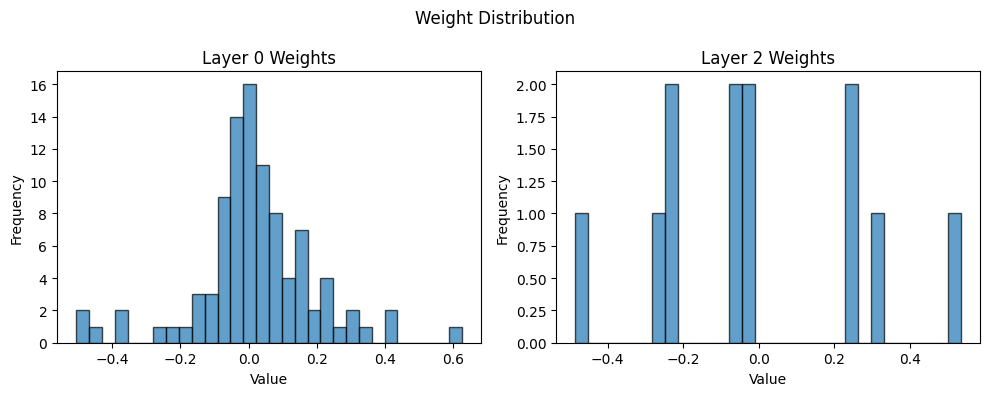

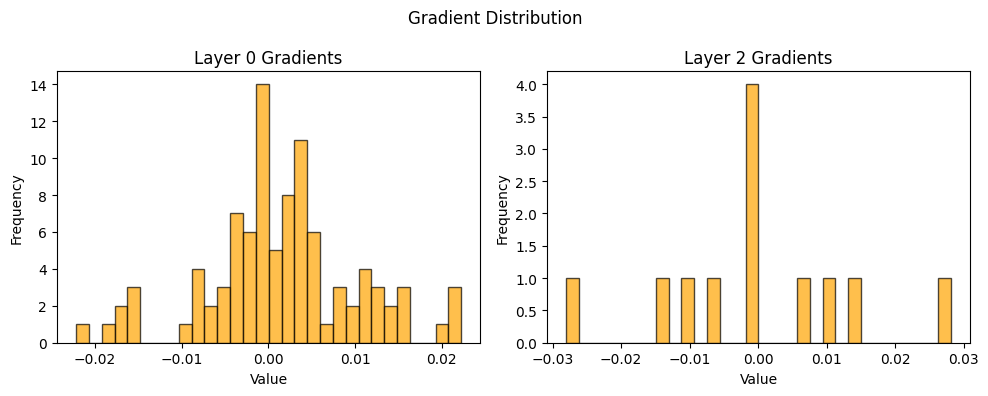

In [210]:
relu_model.plot_weights(hidden_layers)

relu_model.plot_gradients(hidden_layers)

##### Leaky RELU Distribution + Gradient Weight Plot

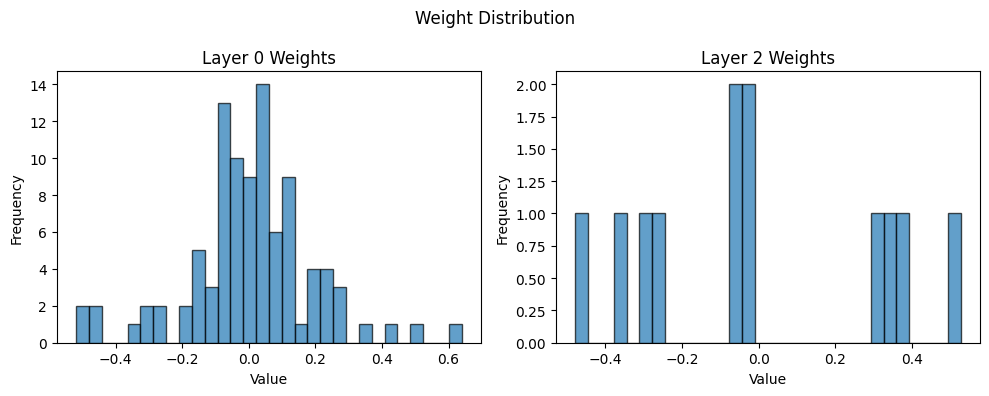

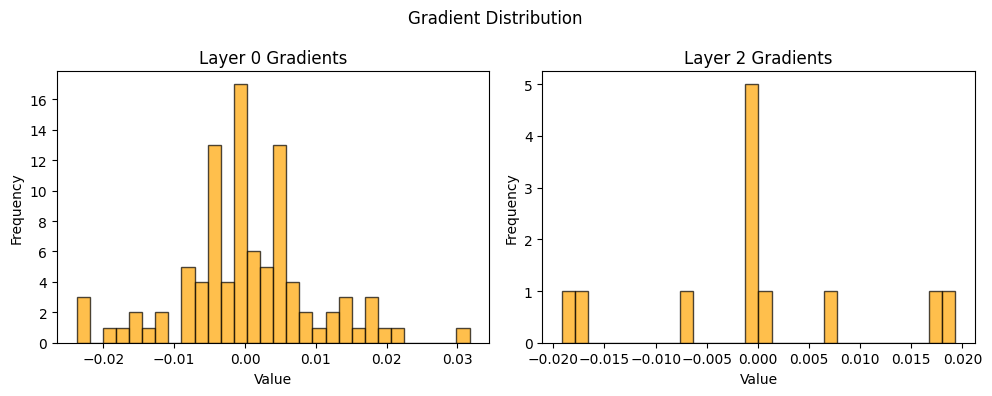

In [211]:
leaky_relu_model.plot_weights(hidden_layers)

leaky_relu_model.plot_gradients(hidden_layers)

##### ELU Distribution + Gradient Weight Plot

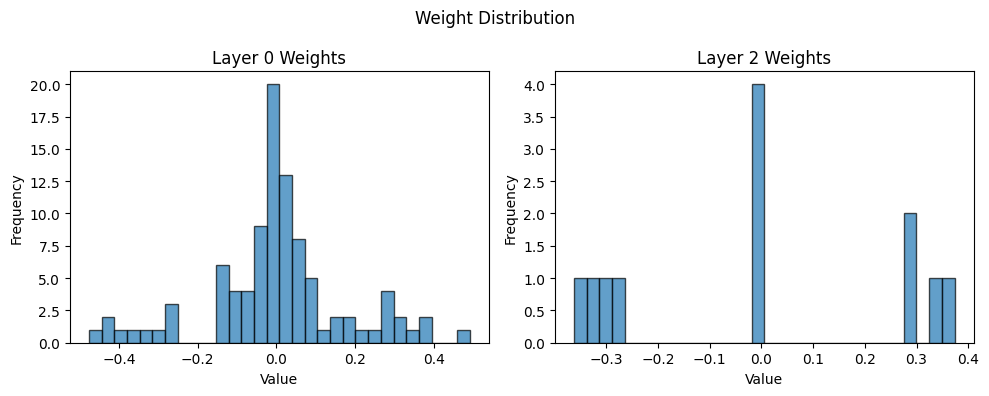

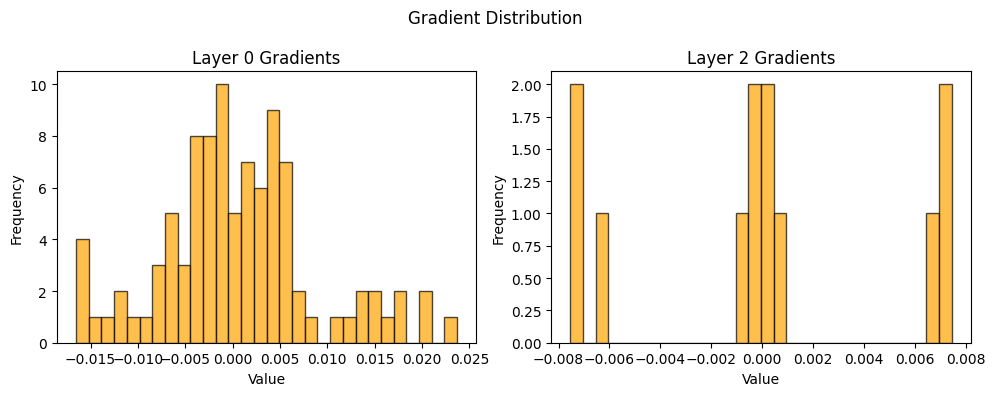

In [212]:
elu_model.plot_weights(hidden_layers)

elu_model.plot_gradients(hidden_layers)

##### RMS Norm Distribution + Gradient Weight Plot

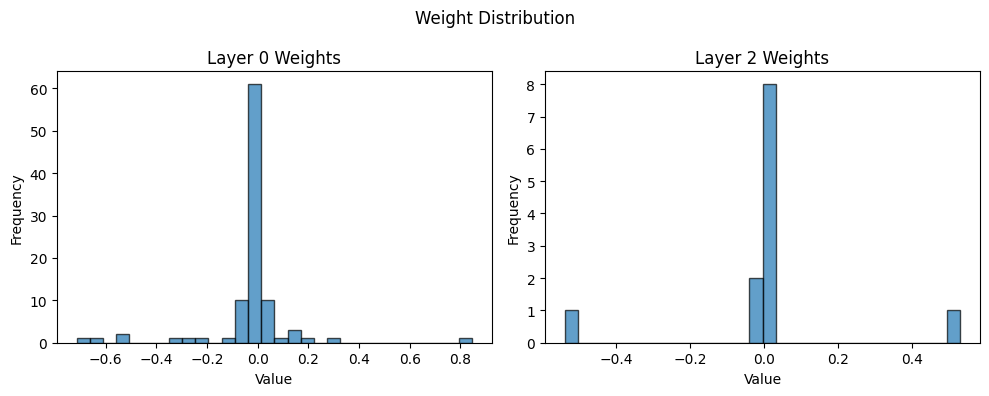

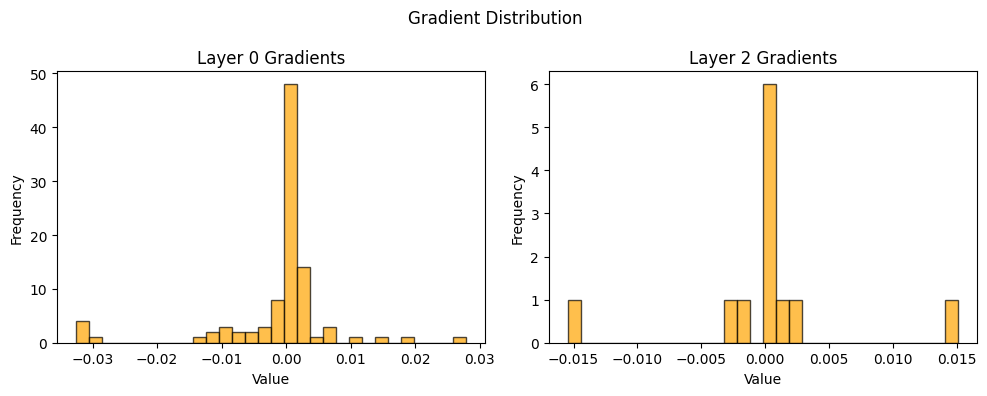

In [213]:
rmsnorm_model.plot_weights(hidden_layers)

rmsnorm_model.plot_gradients(hidden_layers)

##### Tanh Distribution + Gradient Weight Plot

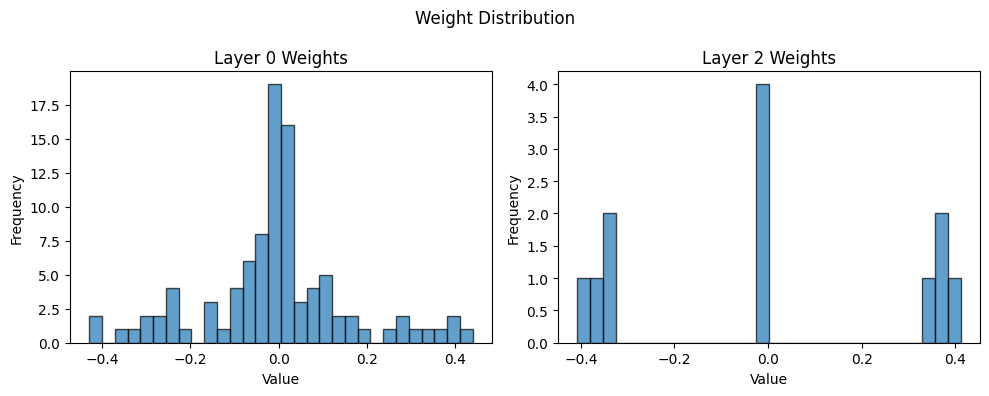

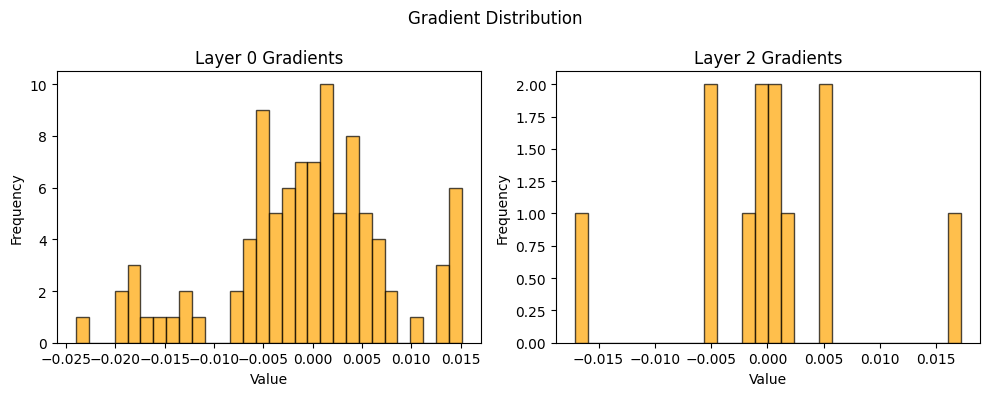

In [214]:
tanh_model.plot_weights(hidden_layers)

tanh_model.plot_gradients(hidden_layers)

##### Sigmoid Distribution + Gradient Weight Plot

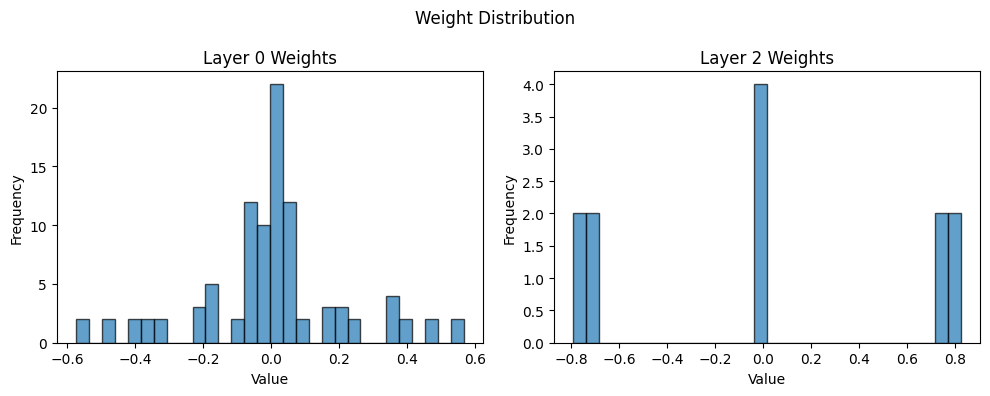

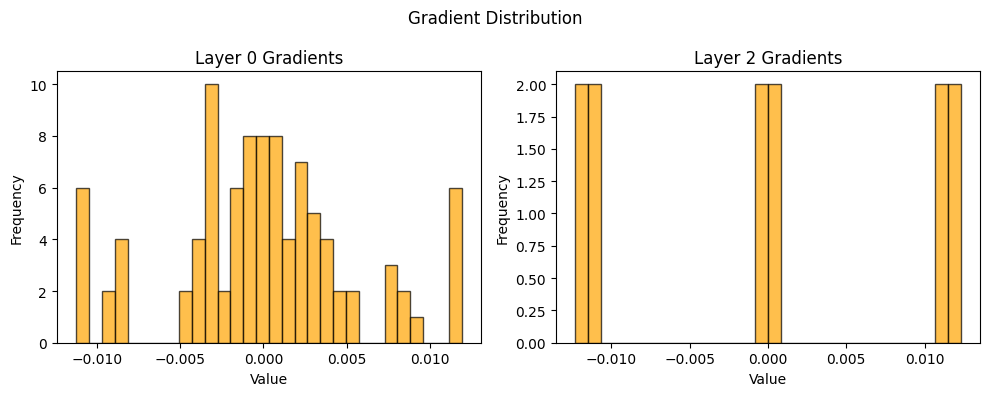

In [215]:
sigmoid_model.plot_weights(hidden_layers)

sigmoid_model.plot_gradients(hidden_layers)

### Three variation of Learning Rate

Using the same control model, we will modify the learning rate when fitting train data

Variation of learning rates:

- 0.01
- 0.1
- 1.1

In [216]:
lr1_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr2_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

lr3_model = ffnn.Model(
    layers=[ffnn.Linear(24, 4), ffnn.Relu(), ffnn.Linear(4, 3), ffnn.Softmax()],
    loss=ffnn.CrossEntropyLoss(),
)

In [217]:
lr1_history = lr1_model.fit(X_train, y_train, epochs=20, lr=0.01, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr1_preds = lr1_model.predict(X_test)
print(f"Learning Rate = 0.1: {f1_score(y_test,lr1_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.902938 - val_loss: 0.914936
Epoch 2/20 [==============================] - train_loss: 0.809920 - val_loss: 0.821388
Epoch 3/20 [==============================] - train_loss: 0.749597 - val_loss: 0.759763
Epoch 4/20 [==============================] - train_loss: 0.706277 - val_loss: 0.715248
Epoch 5/20 [==============================] - train_loss: 0.674312 - val_loss: 0.682312
Epoch 6/20 [==============================] - train_loss: 0.649803 - val_loss: 0.657307
Epoch 7/20 [==============================] - train_loss: 0.630695 - val_loss: 0.637927
Epoch 8/20 [==============================] - train_loss: 0.615496 - val_loss: 0.622309
Epoch 9/20 [==============================] - train_loss: 0.603438 - val_loss: 0.609918
Epoch 10/20 [==============================] - train_loss: 0.593635 - val_loss: 0.600000
Epoch 11/20 [==============================] - train_loss: 0.585410 - val_loss: 0.591838
Epoch 12/20 [=================

In [218]:
lr2_history = lr2_model.fit(X_train, y_train, epochs=20, lr=0.1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr2_preds = lr2_model.predict(X_test)
print(f"Learning Rate = 10: {f1_score(y_test,lr2_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.584149 - val_loss: 0.576699
Epoch 2/20 [==============================] - train_loss: 0.545438 - val_loss: 0.542435
Epoch 3/20 [==============================] - train_loss: 0.532514 - val_loss: 0.531892
Epoch 4/20 [==============================] - train_loss: 0.525749 - val_loss: 0.525575
Epoch 5/20 [==============================] - train_loss: 0.523068 - val_loss: 0.523698
Epoch 6/20 [==============================] - train_loss: 0.521591 - val_loss: 0.521870
Epoch 7/20 [==============================] - train_loss: 0.519151 - val_loss: 0.520177
Epoch 8/20 [==============================] - train_loss: 0.516188 - val_loss: 0.517944
Epoch 9/20 [==============================] - train_loss: 0.516649 - val_loss: 0.518130
Epoch 10/20 [==============================] - train_loss: 0.515300 - val_loss: 0.516578
Epoch 11/20 [==============================] - train_loss: 0.514004 - val_loss: 0.515493
Epoch 12/20 [=================

In [219]:
lr3_history = lr3_model.fit(X_train, y_train, epochs=20, lr=1.1, penalty="l2", lambda_=0.001, validation_data=(X_test, y_test))
lr3_preds = lr3_model.predict(X_test)
print(f"Learning Rate = 40: {f1_score(y_test,lr3_preds)}")

Epoch 1/20 [==============================] - train_loss: 0.528215 - val_loss: 0.536744
Epoch 2/20 [==============================] - train_loss: 0.519501 - val_loss: 0.526570
Epoch 3/20 [==============================] - train_loss: 0.526485 - val_loss: 0.532105
Epoch 4/20 [==============================] - train_loss: 0.514341 - val_loss: 0.513935
Epoch 5/20 [==============================] - train_loss: 0.516591 - val_loss: 0.520776
Epoch 6/20 [==============================] - train_loss: 0.526172 - val_loss: 0.528559
Epoch 7/20 [==============================] - train_loss: 0.516738 - val_loss: 0.521761
Epoch 8/20 [==============================] - train_loss: 0.510652 - val_loss: 0.519163
Epoch 9/20 [==============================] - train_loss: 0.512062 - val_loss: 0.518395
Epoch 10/20 [==============================] - train_loss: 0.513986 - val_loss: 0.519246
Epoch 11/20 [==============================] - train_loss: 0.514193 - val_loss: 0.515533
Epoch 12/20 [=================

#### Perbandingan

In [220]:
print(f"control: {f1_score(y_test,control_preds)}")
print(f"Learning Rate = 0.01: {f1_score(y_test,lr1_preds)}")
print(f"Learning Rate = 0.1: {f1_score(y_test,lr2_preds)}")
print(f"Learning Rate = 1.1: {f1_score(y_test,lr3_preds)}")

control: 0.7680345572354211
Learning Rate = 0.01: 0.7972972972972973
Learning Rate = 0.1: 0.7944647944647945
Learning Rate = 1.1: 0.7714162720619888


In [221]:
lr_layers = [0, 2]

##### lr1 Distribution + Gradient Weight Plot

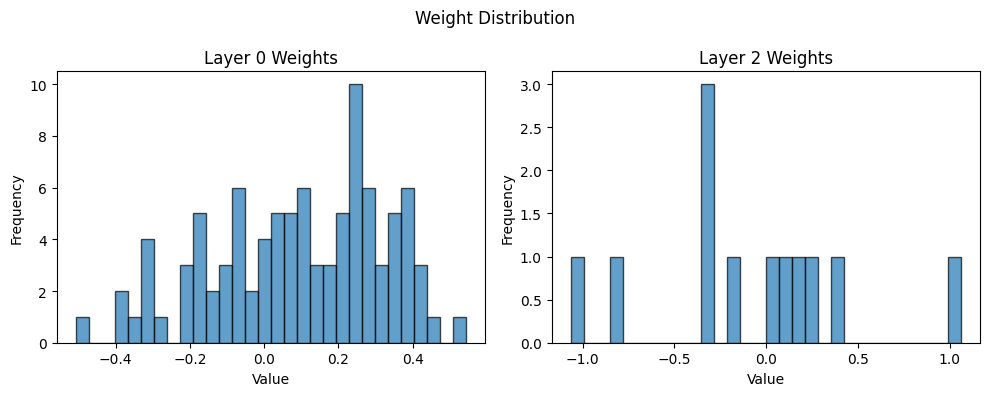

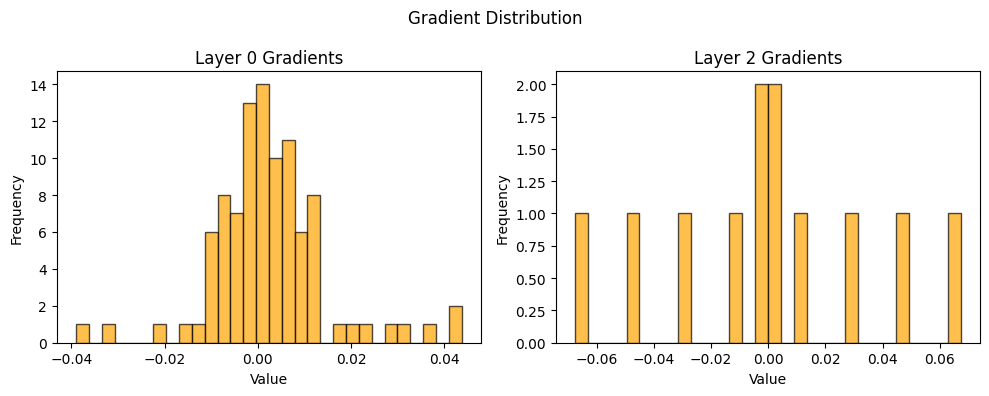

In [222]:
lr1_model.plot_weights(lr_layers)

lr1_model.plot_gradients(lr_layers)

##### lr2 Distribution + Gradient Weight Plot

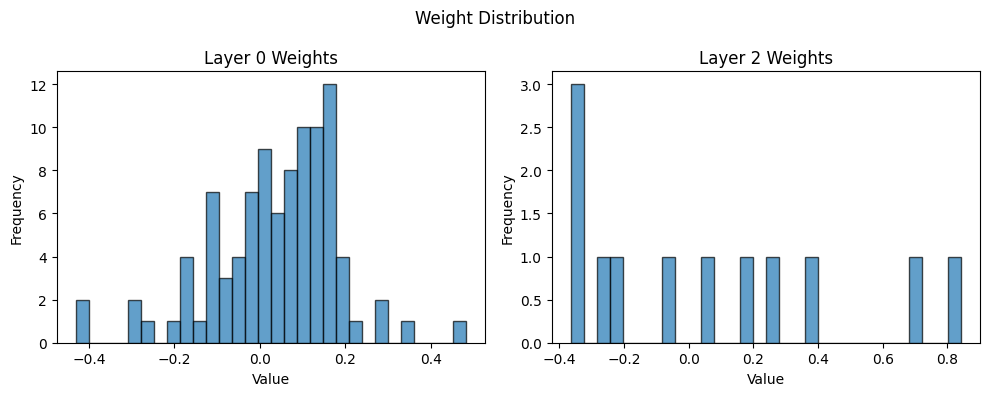

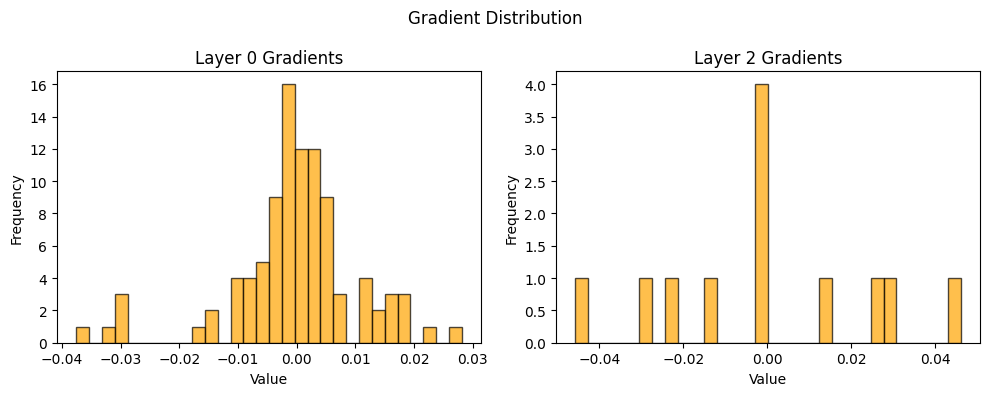

In [223]:
lr2_model.plot_weights(lr_layers)

lr2_model.plot_gradients(lr_layers)

##### lr3 Distribution + Gradient Weight Plot

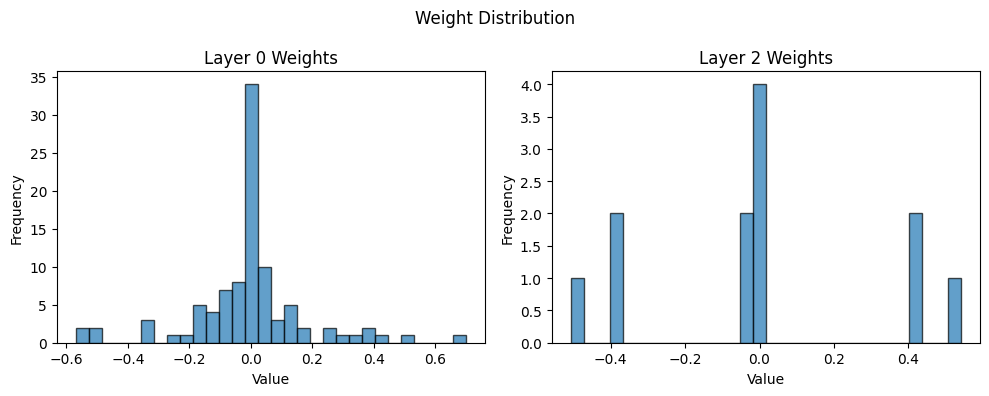

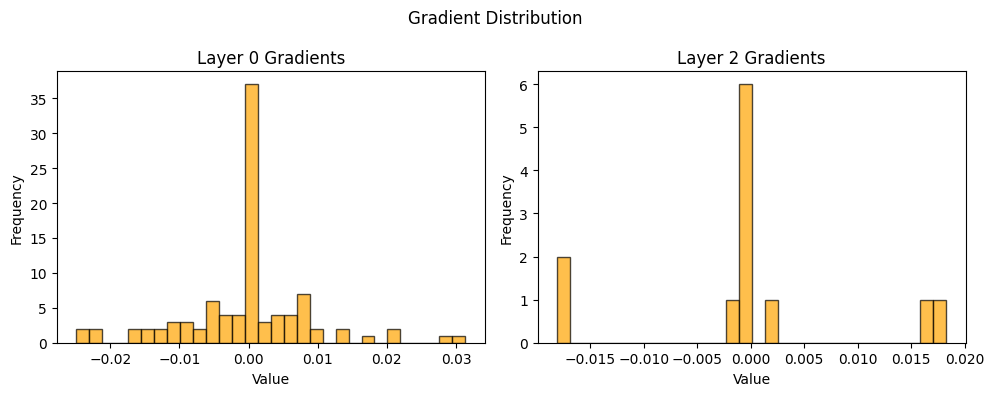

In [224]:
lr3_model.plot_weights(lr_layers)

lr3_model.plot_gradients(lr_layers)

### Training & Validation Loss Graphs

Display Training Loss & Validation Loss on each graph

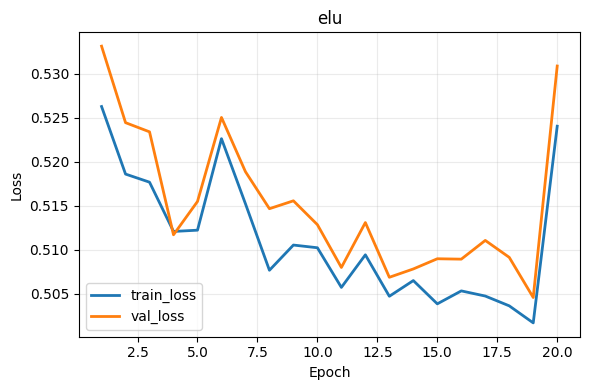

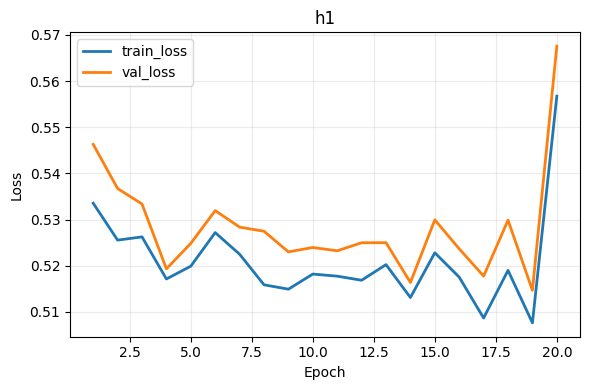

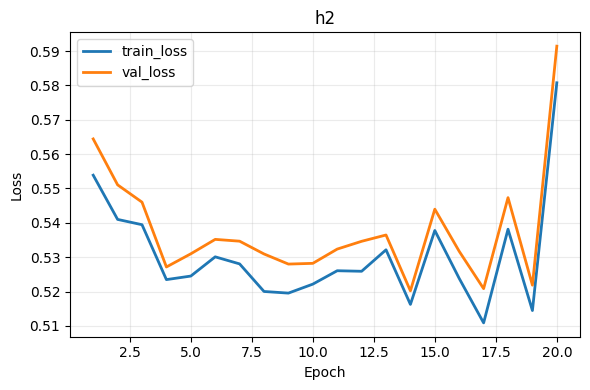

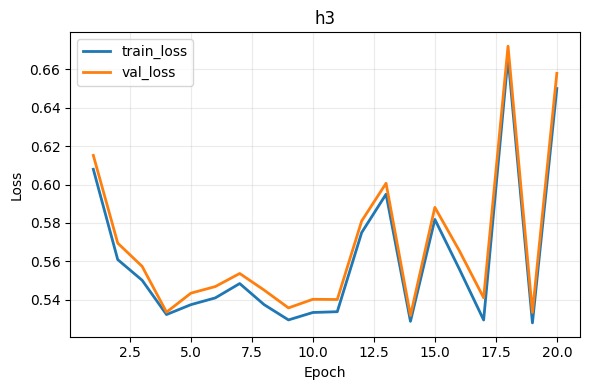

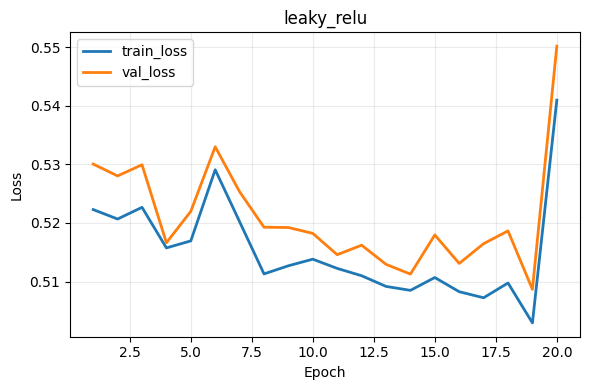

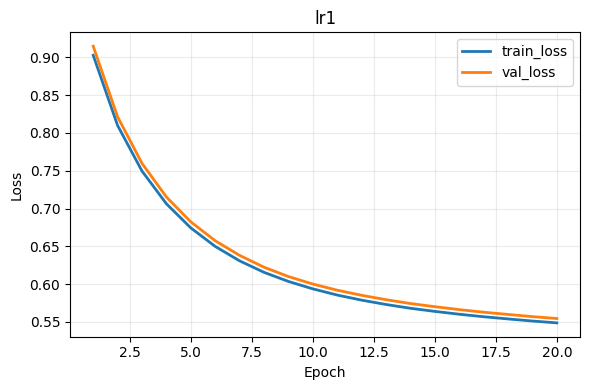

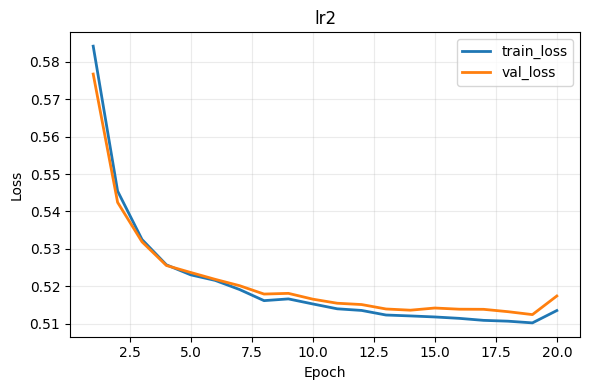

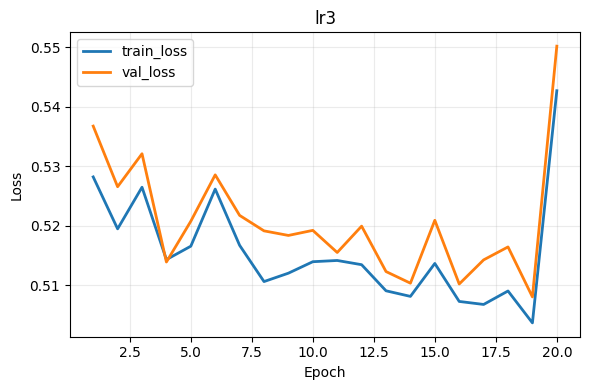

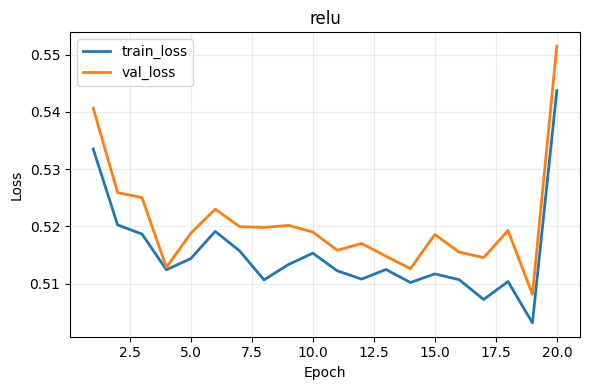

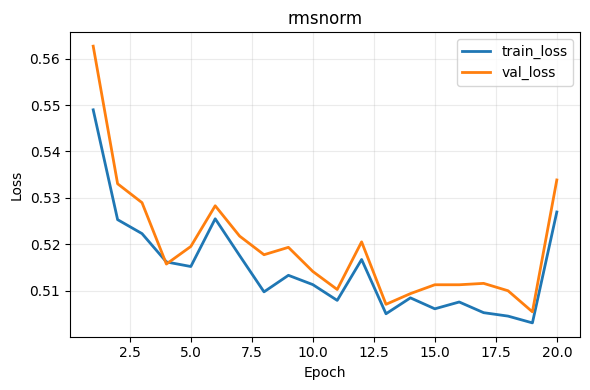

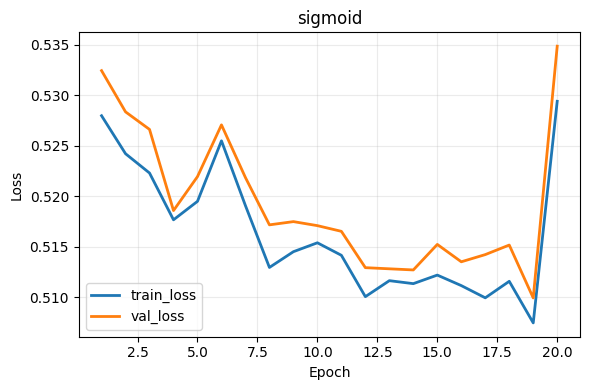

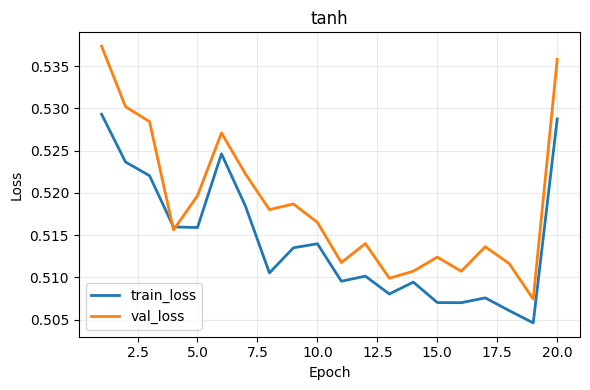

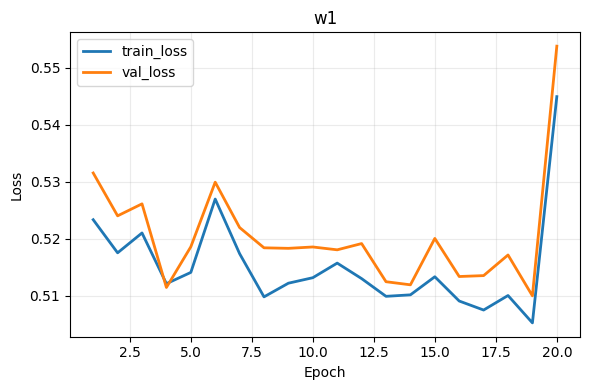

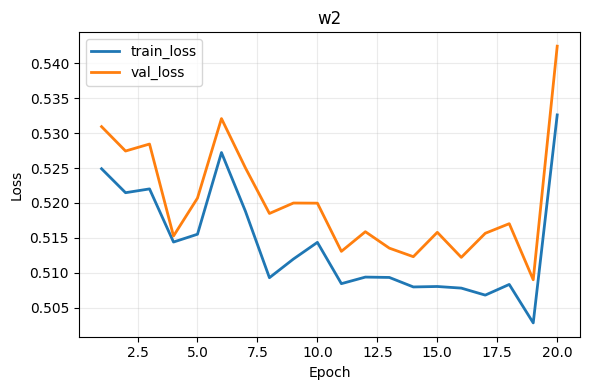

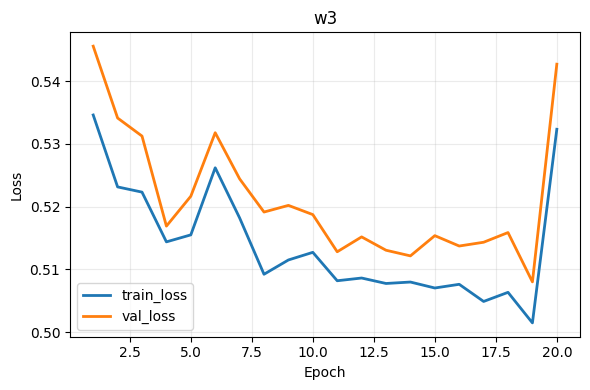

In [225]:
history_items = sorted(
    (name, value)
    for name, value in globals().items()
    if name.endswith("_history") and isinstance(value, dict)
)

if not history_items:
    raise ValueError("No *_history variables found. Run the training cells first.")

for name, history in history_items:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    train_loss = history.get("train_loss", [])
    val_loss = history.get("val_loss", [])

    if train_loss:
        train_epochs = range(1, len(train_loss) + 1)
        ax.plot(train_epochs, train_loss, label="train_loss", linewidth=2)

    if val_loss:
        val_epochs = range(1, len(val_loss) + 1)
        ax.plot(val_epochs, val_loss, label="val_loss", linewidth=2)
    else:
        ax.text(
            0.5,
            0.1,
            "val_loss unavailable",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=9,
            color="gray",
        )

    ax.set_title(name.replace("_history", ""))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()